# 3. MC context lambda

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/group_meta.tsv'`  ·  _metadata_
- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `'mC_context/cell_93350_lambda_context_mc.tsv.gz'`  ·  _lambda control_
- `'mC_context/cell_93350_lambda_context_cov.tsv.gz'`  ·  _lambda control_
- `'mC_context/L2any-donor_context.hdf'`  ·  _other_
- `'mC_context/L2any-donor_lambda_context.hdf'`  ·  _lambda control_
- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}merged_allc/cluster_donor.mcds'`  ·  _sc/pseudobulk mC (allc)_
- `'mC_context/L2any_mCA_025_top2_rawratio.hdf'`  ·  _other_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from glob import glob

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, roc_auc_score

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing 

In [2]:
indir = f'{ENTEX_ROOT}/'
file_list = np.sort(glob(f'{indir}analysis/mC_context/L2any-donor/*.context.tsv'))


In [3]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# group_meta = group_meta[['L2_any', 'L1', 'count']]
group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ','-').str.replace('/','_')
annot2L1 = group_meta[['L1','L1_annot']].set_index('L1_annot')['L1'].to_dict()
L1annot = group_meta[['L1','L1_annot']].set_index('L1')['L1_annot'].to_dict()


In [4]:
mc, cov, cluster = [], [], []
for file in file_list:
    tmp = pd.read_csv(file, index_col=0, header=None, names=['context', 'mc', 'cov'], sep='\t')
    mc.append(tmp['mc'])
    cov.append(tmp['cov'])
    cluster.append(file.split('/')[-1].split('.')[0])
    

In [5]:
mc = pd.concat(mc, axis=1)
mc.columns = cluster
cov = pd.concat(cov, axis=1)
cov.columns = cluster


In [6]:
selc = np.array([('N' not in xx) for xx in mc.index])
mc = mc.loc[selc].T
cov = cov.loc[selc].T


In [7]:
mc.to_hdf('mC_context/L2any-donor_context.hdf', key='mc')
cov.to_hdf('mC_context/L2any-donor_context.hdf', key='cov')


In [7]:
adata = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')
adata

AnnData object with n_obs × n_vars = 86689 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1', 'leiden_cons', 'leiden_cv', 'leiden_init', 'batch', 'L1_annot', 'L1', 'L2', 'L2_any', 'L2_both', 'L2_mc', 'L2_3c', 'tissue_annot', 'group', 'cluster', 'Short/Long', 'mcg_L2', 'hic_L2', 'L2_final'
    obsm: '100k3C_pc50_seuratL2_tsne', '5kCG100k3C_u50pc50_tsne', '5kCG_u50_seuratL2_tsne', 'X_tsne'

In [8]:
mc_lambda = pd.read_csv('mC_context/cell_93350_lambda_context_mc.tsv.gz', sep='\t', header=0, index_col=0).loc[adata.obs.index]
cov_lambda = pd.read_csv('mC_context/cell_93350_lambda_context_cov.tsv.gz', sep='\t', header=0, index_col=0).loc[adata.obs.index]


In [9]:
mc_lambda = mc_lambda.groupby(adata.obs['group']).sum().loc[mc.index]
cov_lambda = cov_lambda.groupby(adata.obs['group']).sum().loc[cov.index]

In [10]:
mc_lambda.index = mc_lambda.index.astype(str)
cov_lambda.index = cov_lambda.index.astype(str)


In [45]:
mc_lambda.to_hdf('mC_context/L2any-donor_lambda_context.hdf', key='mc')
cov_lambda.to_hdf('mC_context/L2any-donor_lambda_context.hdf', key='cov')


In [4]:
mc = pd.read_hdf('mC_context/L2any-donor_context.hdf', key='mc')
cov = pd.read_hdf('mC_context/L2any-donor_context.hdf', key='cov')
mc_lambda = pd.read_hdf('mC_context/L2any-donor_lambda_context.hdf', key='mc')
cov_lambda = pd.read_hdf('mC_context/L2any-donor_lambda_context.hdf', key='cov')


In [9]:
selch = np.array([(xx[:2]!='CG') for xx in mc.columns])


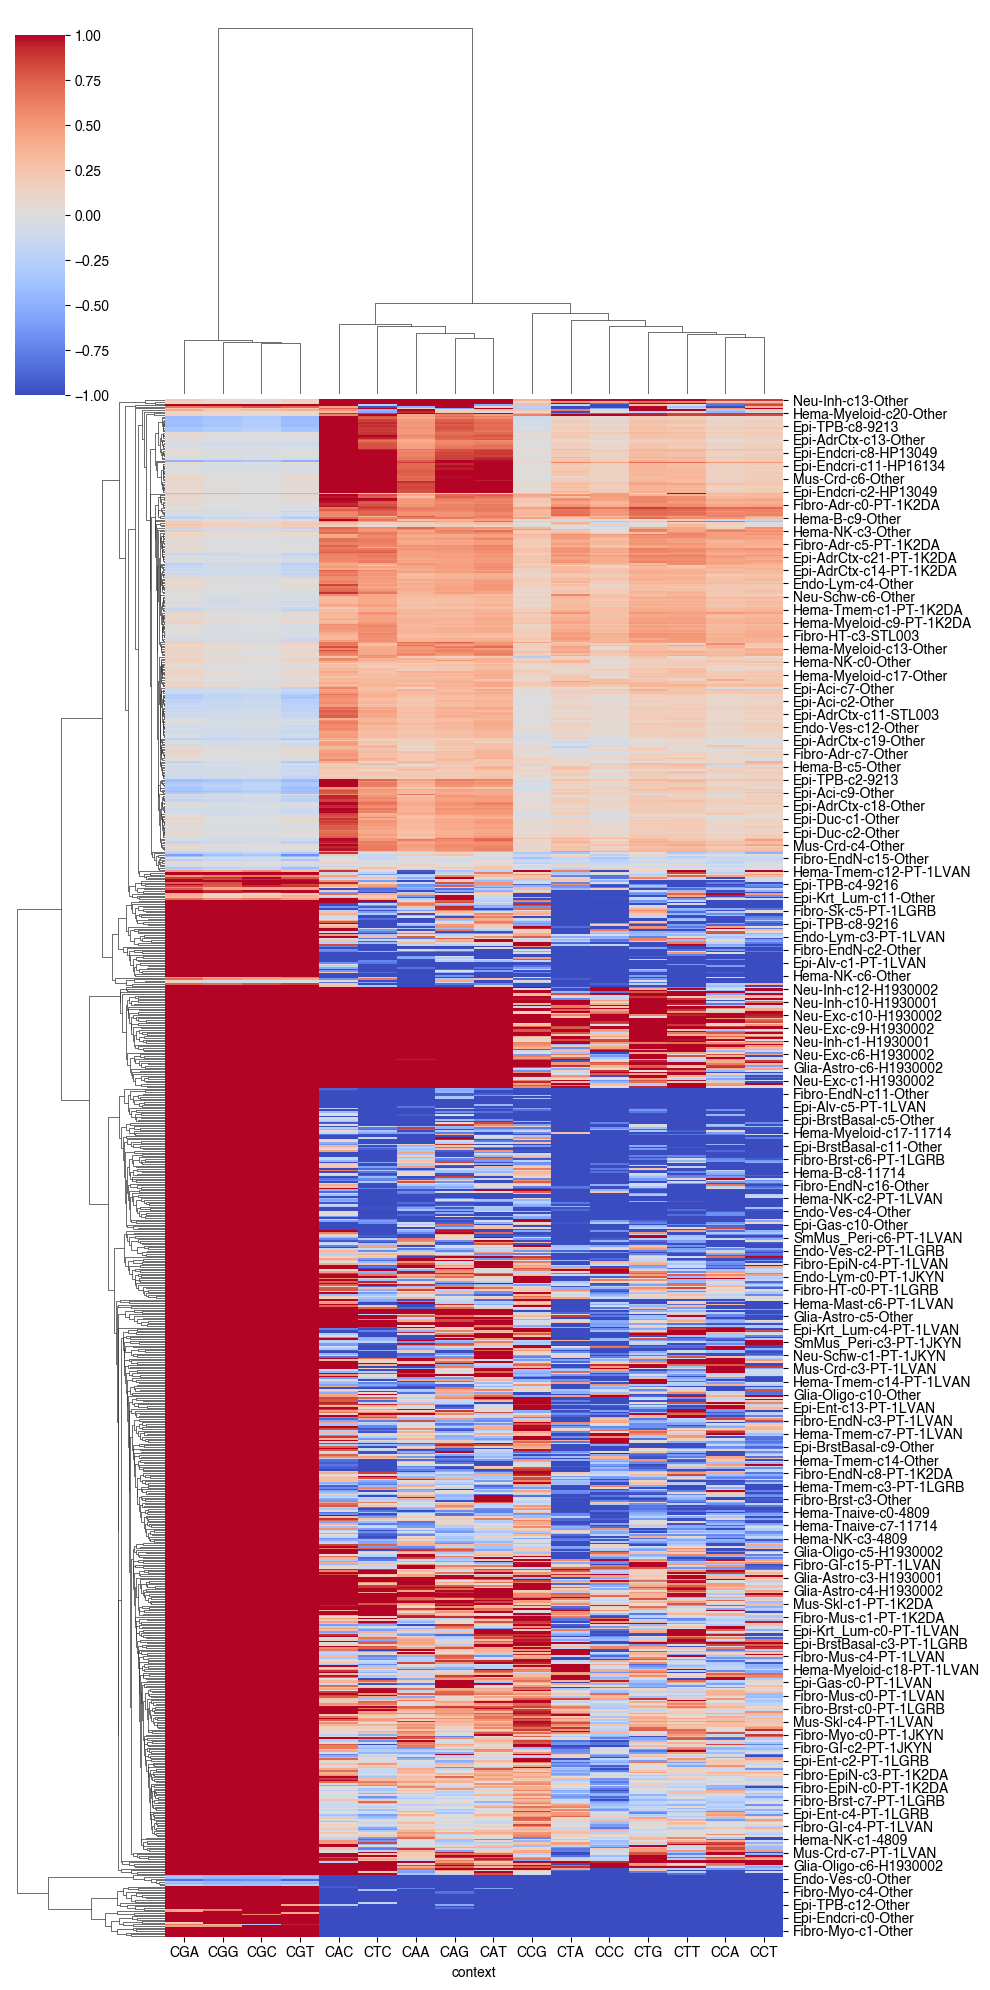

In [5]:
tmp = np.log2(((mc+1)/(cov+1))/((mc_lambda+1)/(cov_lambda+1)))
tmp.index = ['-'.join([L1annot[xx.split('-')[0]]] + xx.split('-')[1:]) for xx in tmp.index]
sns.clustermap(tmp, cmap='coolwarm', vmax=1, vmin=-1, figsize=(10,20), yticklabels=8, metric='euclidean')

In [16]:
groupL2 = pd.Series(['-'.join(xx.split('-')[:2]) for xx in mc.index], index=mc.index)
mc_L2 = mc.groupby(groupL2).sum()
cov_L2 = cov.groupby(groupL2).sum()
mc_lambda_L2 = mc_lambda.groupby(groupL2).sum()
cov_lambda_L2 = cov_lambda.groupby(groupL2).sum()

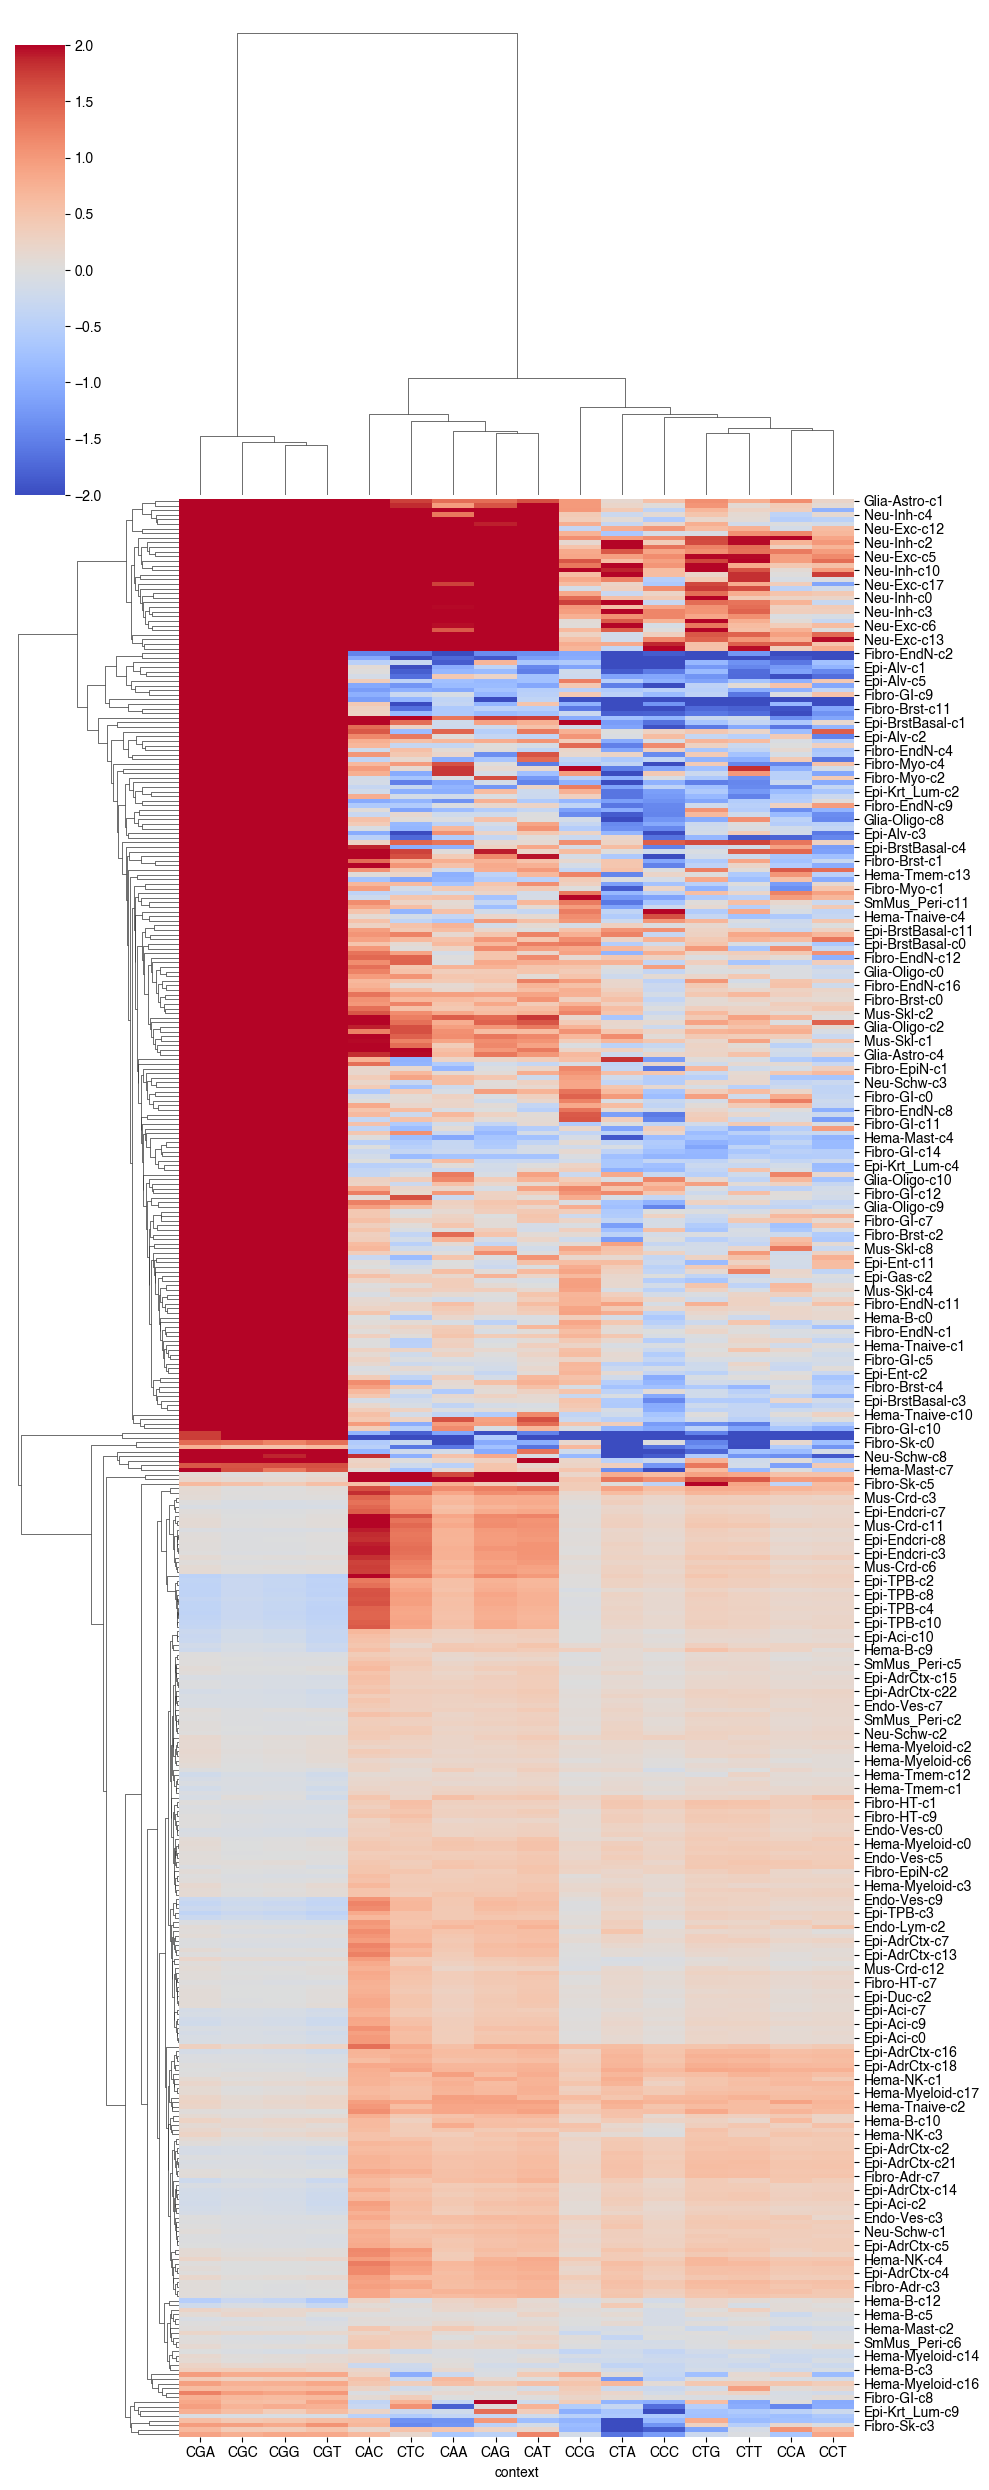

In [17]:
tmp = np.log2(((mc_L2+1)/(cov_L2+1))/((mc_lambda_L2+1)/(cov_lambda_L2+1)))
tmp.index = ['-'.join([L1annot[xx.split('-')[0]]] + xx.split('-')[1:]) for xx in tmp.index]
sns.clustermap(tmp, cmap='coolwarm', vmax=2, vmin=-2, figsize=(10,25), yticklabels=3, metric='euclidean')

In [10]:
groupL1 = pd.Series(mc.index.str.split('-').str[0], index=mc.index)
mc_L1 = mc.groupby(groupL1).sum().loc[:, selch]
cov_L1 = cov.groupby(groupL1).sum().loc[:, selch]
mc_lambda_L1 = mc_lambda.groupby(groupL1).sum().loc[:, selch]
cov_lambda_L1 = cov_lambda.groupby(groupL1).sum().loc[:, selch]


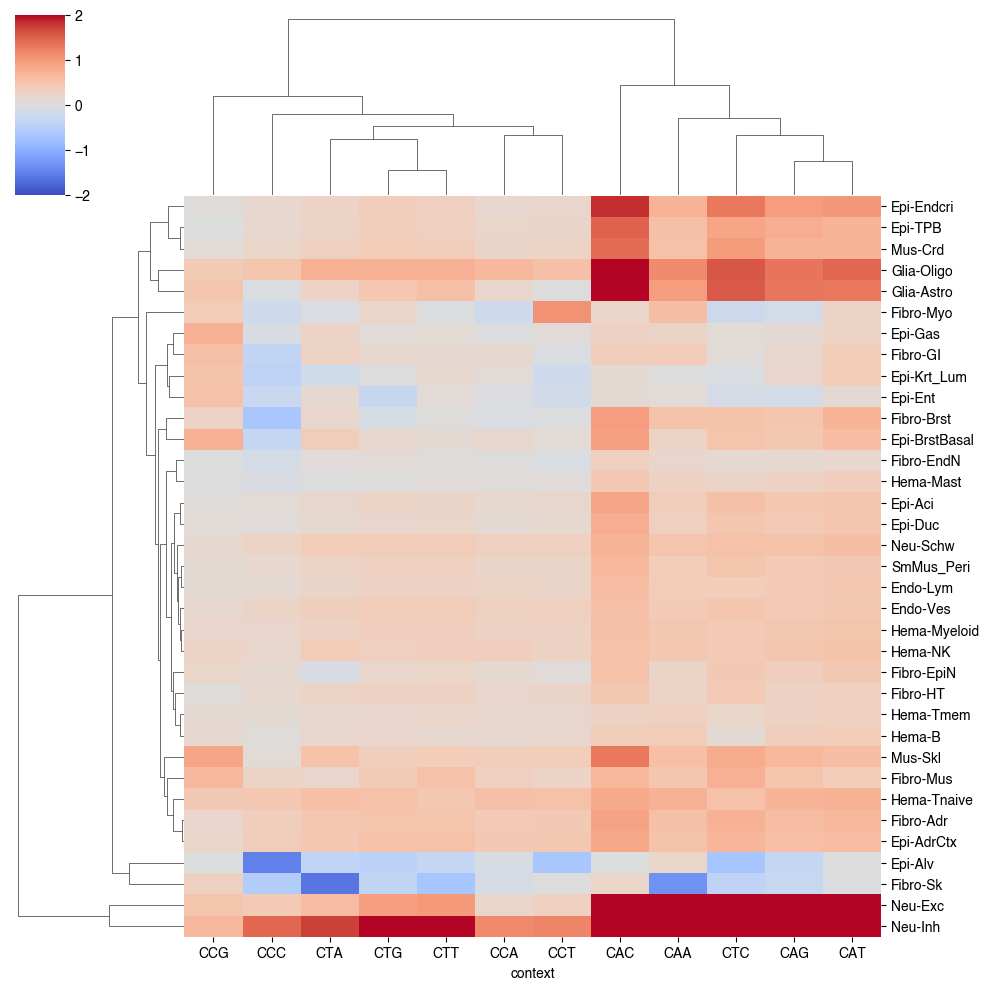

In [31]:
tmp = np.log2(((mc_L1+1)/(cov_L1+1))/((mc_lambda_L1+1)/(cov_lambda_L1+1)))
tmp.index = ['-'.join([L1annot[xx.split('-')[0]]] + xx.split('-')[1:]) for xx in tmp.index]
sns.clustermap(tmp, cmap='coolwarm', vmax=2, vmin=-2, figsize=(10,10), yticklabels=1, metric='euclidean')
import matplotlib.pyplot as _plt; _plt.savefig('mC_context/L1_mCH_lambda_log2fc_heatmap.pdf', transparent=True)  # Fig S16A (mCH/Lambda fold-change) — tentative


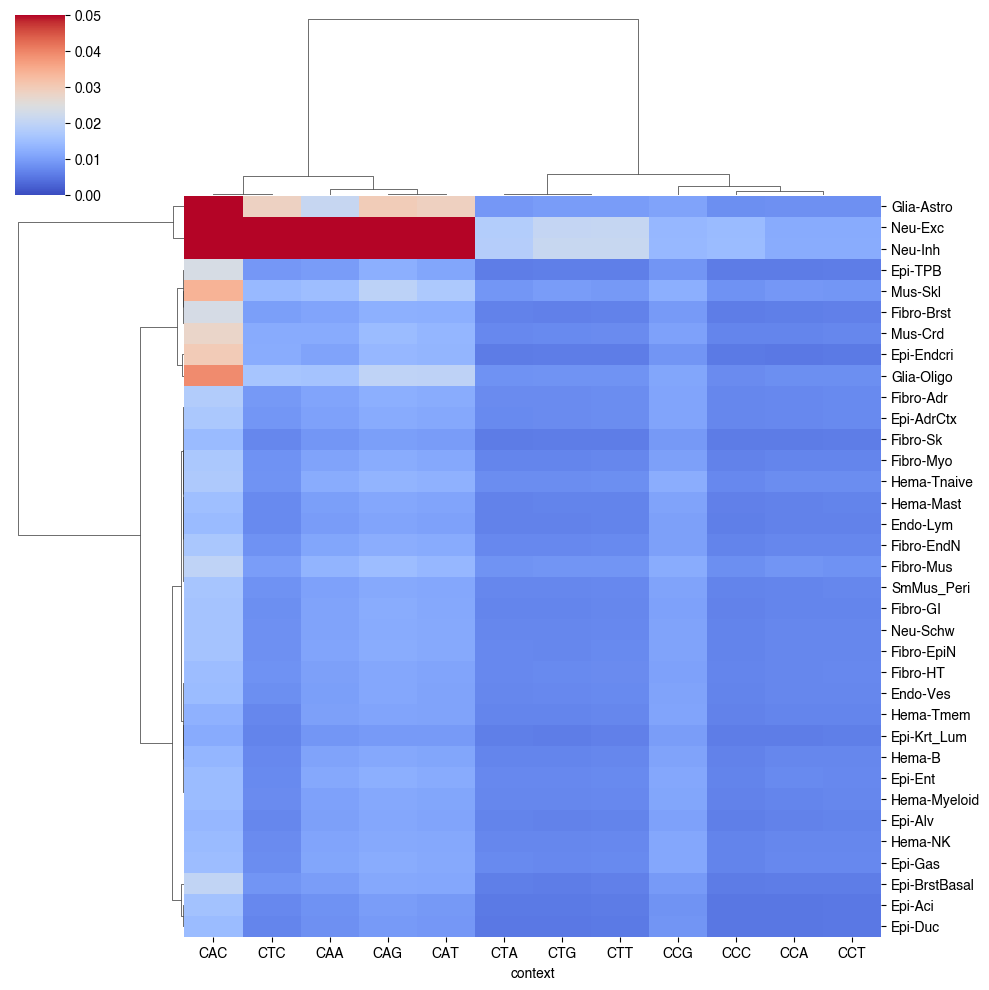

In [37]:
tmp = (mc_L1+1)/(cov_L1+1)
tmp.index = ['-'.join([L1annot[xx.split('-')[0]]] + xx.split('-')[1:]) for xx in tmp.index]
sns.clustermap(tmp, cmap='coolwarm', vmax=0.05, vmin=0, figsize=(10,10), yticklabels=1, metric='cosine')
import matplotlib.pyplot as _plt; _plt.savefig('mC_context/L1_mCH_heatmap.pdf', transparent=True)  # Fig S16B (mCH) — tentative


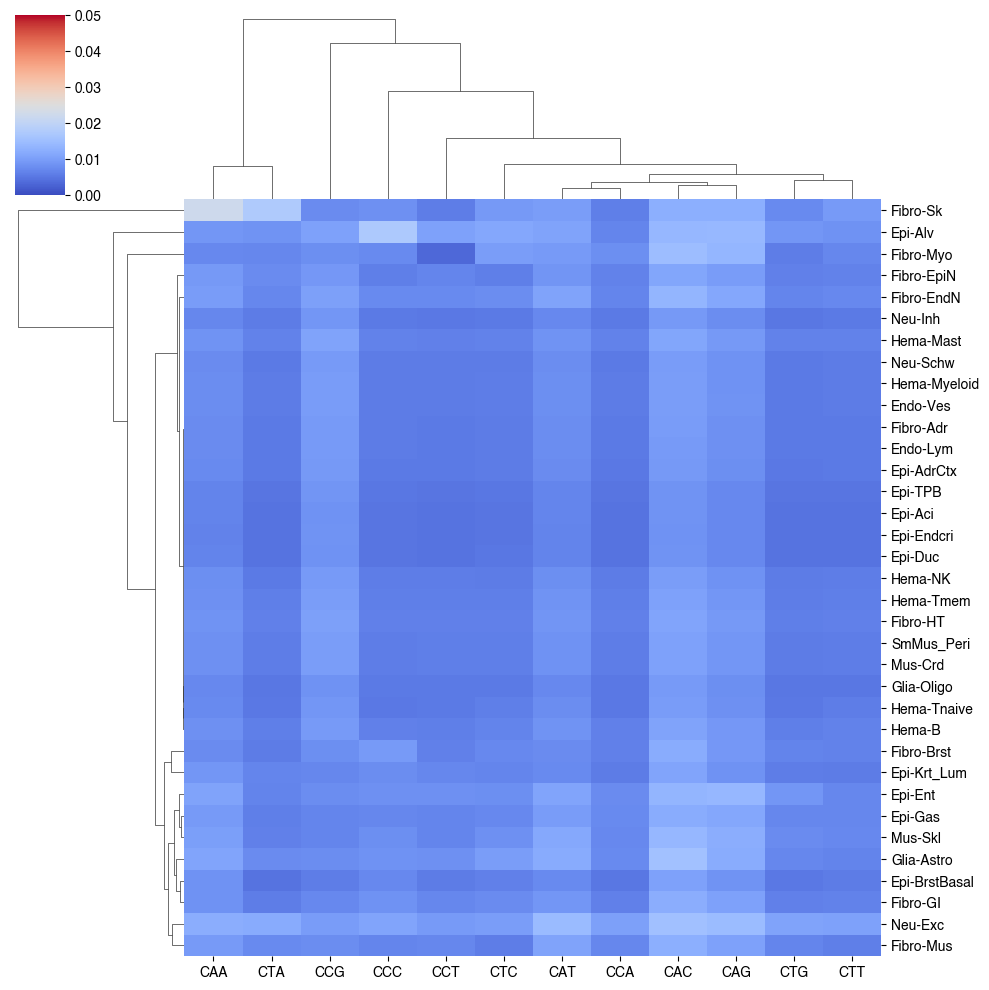

In [38]:
tmp = (mc_lambda_L1+1)/(cov_lambda_L1+1)
tmp.index = ['-'.join([L1annot[xx.split('-')[0]]] + xx.split('-')[1:]) for xx in tmp.index]
sns.clustermap(tmp, cmap='coolwarm', vmax=0.05, vmin=0, figsize=(10,10), yticklabels=1, metric='cosine')


In [11]:
colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color'].to_dict()


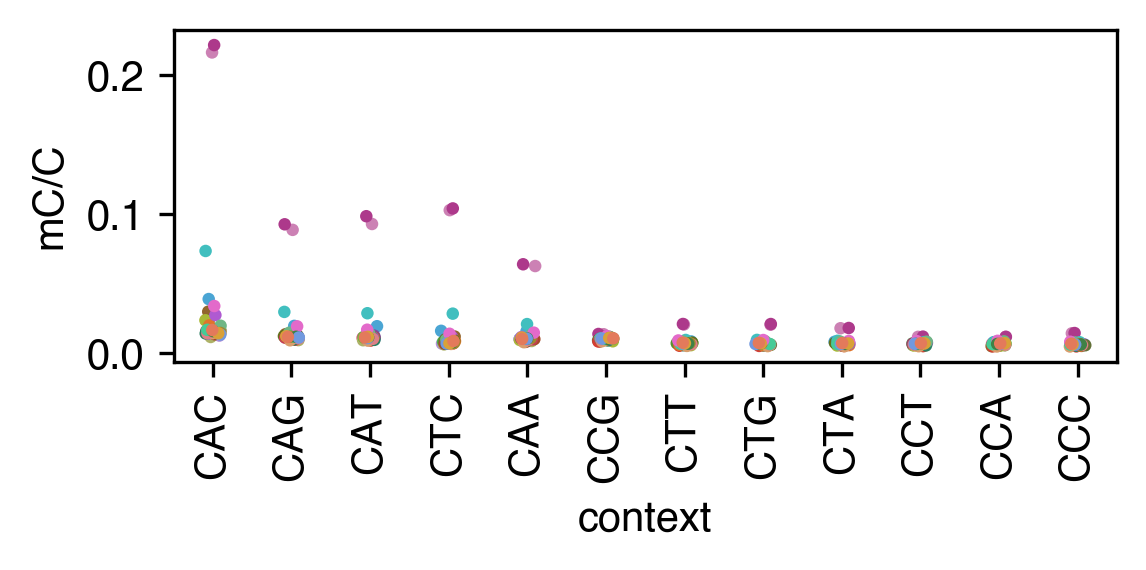

In [15]:
tmp = (mc_L1+1)/(cov_L1+1)
tmp.index.name = 'L1'
tmp = tmp.stack().reset_index()
selc = tmp['L1'].isin(['c10', 'c16', 'c31'])
leg_order = tmp.groupby('context')[0].mean().sort_values().index[::-1]

fig, ax = plt.subplots(figsize=(4,2),dpi=300)
sns.stripplot(data=tmp, x='context', y=0, hue='L1', palette=colors, 
              order=leg_order, ax=ax, edgecolor='none', s=3)
ax.set_xticks(np.arange(selch.sum()))
ax.set_xticklabels(leg_order, rotation=90)
ax.set_ylabel('mC/C')
ax.get_legend().remove()
fig.tight_layout()


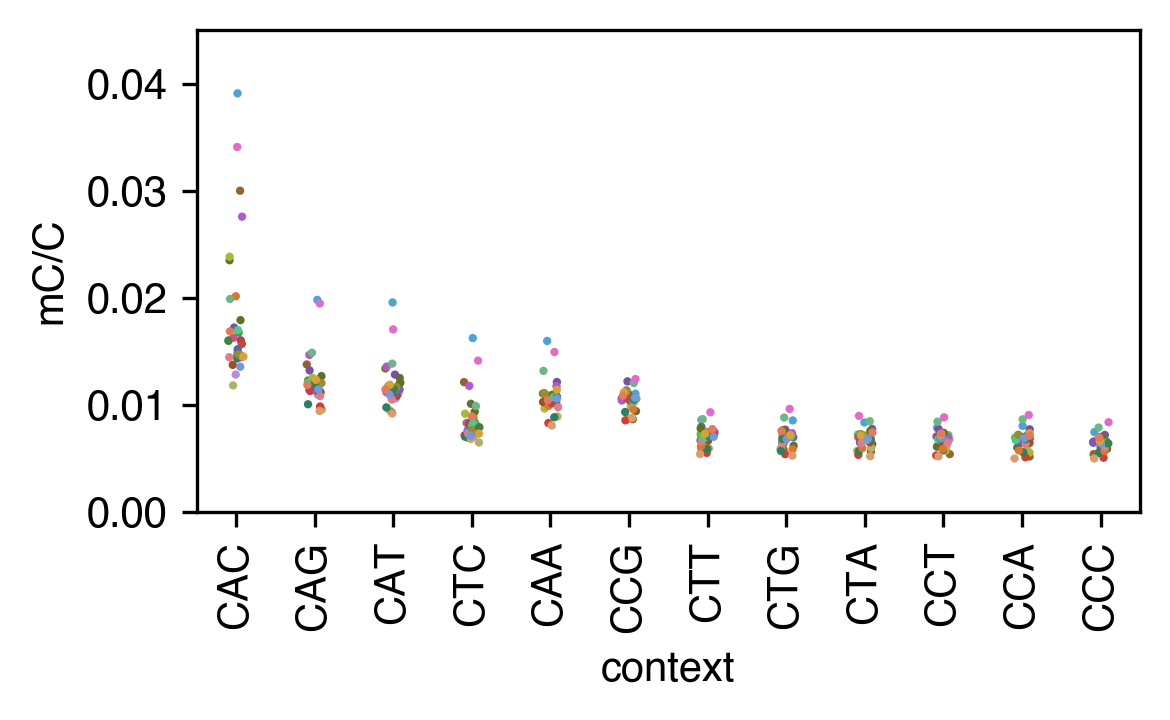

In [19]:
# tmp = (mc_L1+1)/(cov_L1+1)
# tmp.index.name = 'L1'
# tmp = tmp.stack().reset_index()
# selc = tmp['L1'].isin(['c10', 'c16', 'c31'])
# leg_order = tmp.groupby('context')[0].mean().sort_values().index[::-1]

fig, ax = plt.subplots(figsize=(4,2.5),dpi=300)
sns.stripplot(data=tmp.loc[~selc], x='context', y=0, hue='L1', palette=colors, 
              order=leg_order, ax=ax, edgecolor='none', s=2)
ax.set_ylim([0, 0.045])
ax.set_yticks(np.arange(0, 0.05, 0.01))
ax.set_xticks(np.arange(selch.sum()))
ax.set_xticklabels(leg_order, rotation=90)
ax.set_ylabel('mC/C')
ax.get_legend().remove()
fig.tight_layout()
fig.savefig('mCH_distribution/L1_context_scatter.pdf', transparent=True)


In [25]:
mc_ch_L2 = mc_L2.loc[:, selch]#.sum(axis=1)
cov_ch_L2 = cov_L2.loc[:, selch]#.sum(axis=1)
mc_lambda_ch_L2 = mc_lambda_L2.loc[:, selch]#.sum(axis=1)
cov_lambda_ch_L2 = cov_lambda_L2.loc[:, selch]#.sum(axis=1)


In [53]:
L1_color = pd.read_csv(f'{indir}L1color.tsv', sep='\t', index_col=0, header=0)

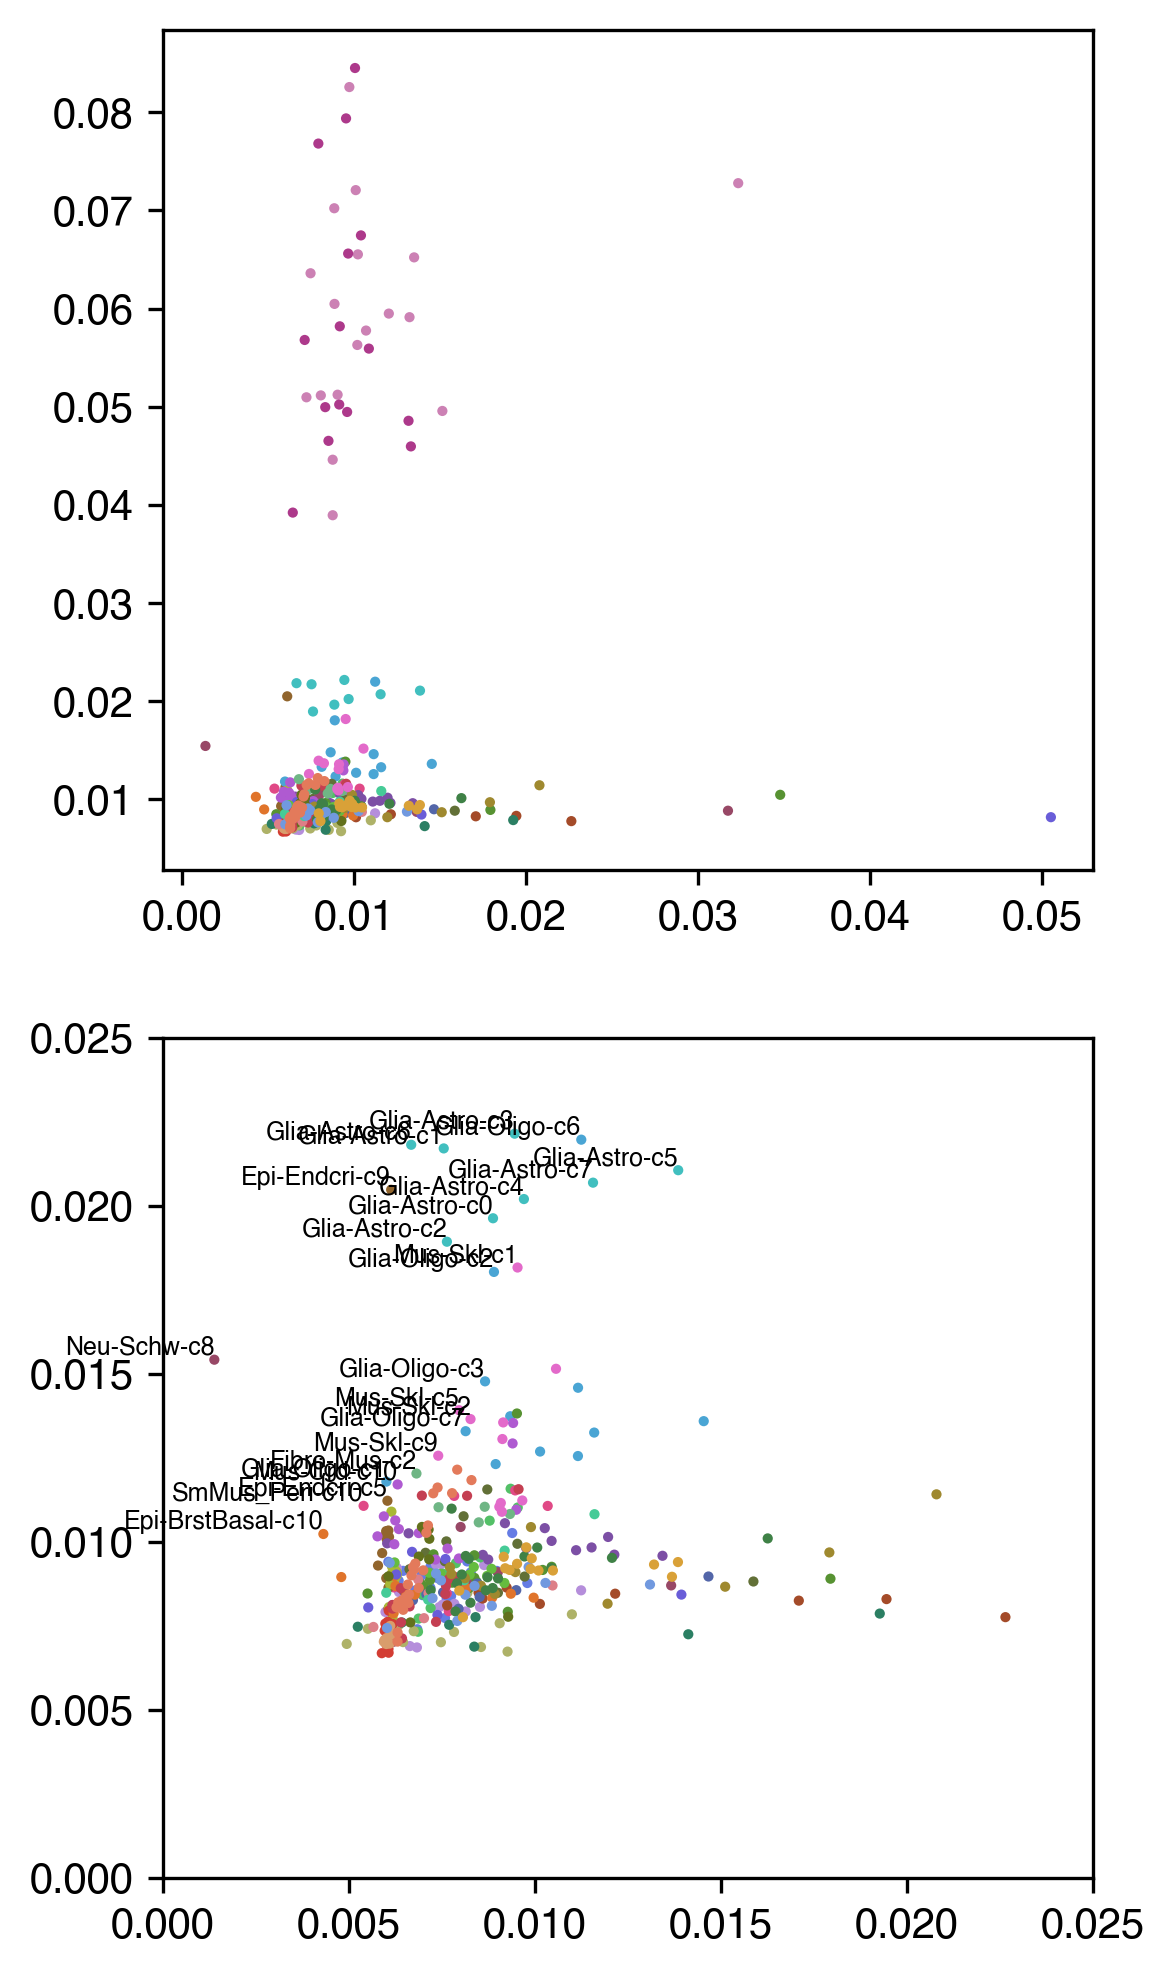

In [76]:
color = mc_ch_L2.index.str.split('-').str[0].map(L1_color['color'])
lambda_ch_L2 = mc_lambda_ch_L2/cov_lambda_ch_L2
ch_L2 = mc_ch_L2/cov_ch_L2

fig, axes = plt.subplots(2, 1, figsize=(4,8), dpi=300)
ax = axes[0]
ax.scatter(lambda_ch_L2, ch_L2, c=color, s=6, edgecolor='none')
ax = axes[1]
ax.scatter(lambda_ch_L2, ch_L2, c=color, s=6, edgecolor='none')
ax.set_xlim([0, 0.025])
ax.set_ylim([0, 0.025])
selc = ch_L2.index[(ch_L2-lambda_ch_L2>0.005) & (ch_L2<0.025)]
for xx in selc:
    ax.text(lambda_ch_L2.loc[xx], ch_L2.loc[xx], f'{L1annot[xx.split("-")[0]]}-{xx.split("-")[1]}', fontsize=6, ha='right', va='bottom')


In [77]:
selc

Index(['c12-c10', 'c13-c5', 'c13-c9', 'c14-c1', 'c14-c2', 'c14-c3', 'c14-c6',
       'c14-c7', 'c21-c8', 'c25-c10', 'c26-c10', 'c31-c0', 'c31-c1', 'c31-c2',
       'c31-c3', 'c31-c4', 'c31-c5', 'c31-c6', 'c31-c7', 'c32-c2', 'c5-c1',
       'c5-c2', 'c5-c5', 'c5-c9'],
      dtype='object', name='L2_any')

In [6]:
selcg = np.array([(xx[:2]=='CG') for xx in mc.columns])
selch = np.array([(xx[:2]!='CG') for xx in mc.columns])
mc_cg = mc.loc[:, selcg]
cov_cg = cov.loc[:, selcg]
mc_ch = mc.loc[:, selch]
cov_ch = cov.loc[:, selch]


In [8]:
tmp = (mc_ch / cov_ch)
tmp = pd.DataFrame(tmp.max(axis=1).sort_values()[::-1])
tmp['L1'] = tmp.index.str.split('-').str[0].map(L1annot)
tmp = tmp.groupby('L1').head(2)

In [9]:
selc = tmp.index[tmp[0]>0.025]
selc

Index(['c16-c1', 'c10-c9', 'c16-c2', 'c10-c2', 'c31-c1', 'c13-c9', 'c31-c3',
       'c14-c6', 'c14-c2', 'c5-c1', 'c21-c8', 'c19-c12', 'c5-c2', 'c13-c5',
       'c2-c7', 'c26-c11', 'c26-c0', 'c17-c8', 'c17-c1', 'c3-c15', 'c12-c9',
       'c6-c12', 'c2-c5', 'c4-c9'],
      dtype='object')

In [10]:
tmp.loc[selc]

,0,L1
c16-c1,0.305308,Neu-Inh
c10-c9,0.299201,Neu-Exc
c16-c2,0.287272,Neu-Inh
c10-c2,0.266839,Neu-Exc
c31-c1,0.078849,Glia-Astro
c13-c9,0.077851,Epi-Endcri
c31-c3,0.077342,Glia-Astro
c14-c6,0.074059,Glia-Oligo
c14-c2,0.059231,Glia-Oligo
c5-c1,0.057213,Mus-Skl


In [ ]:
selc = pd.Index(['c12-c10', 'c13-c5', 'c13-c9', 'c14-c1', 'c14-c2', 'c14-c3', 'c14-c6',
       'c14-c7', 'c21-c8', 'c25-c10', 'c26-c10', 'c31-c0', 'c31-c1', 'c31-c2',
       'c31-c3', 'c31-c4', 'c31-c5', 'c31-c6', 'c31-c7', 'c32-c2', 'c5-c1',
       'c5-c2', 'c5-c5', 'c5-c9'])

In [11]:
from ALLCools.mcds import MCDS

mcds = MCDS.open(f'{indir}merged_allc/cluster_donor.mcds', var_dim='chrom1k')
mcds

<xarray.MCDS> Size: 93GB
Dimensions:        (cell: 940, chrom1k: 3088298, count_type: 2, mc_type: 4)
Coordinates:
  * cell           (cell) <U16 60kB 'c0-c0-PT-1JKYN' ... 'c9-c9-STL003'
  * chrom1k        (chrom1k) <U12 148MB 'chr1_0' 'chr1_1' ... 'chrY_57227'
    chrom1k_chrom  (chrom1k) <U5 62MB ...
    chrom1k_end    (chrom1k) int64 25MB ...
    chrom1k_start  (chrom1k) int64 25MB ...
  * count_type     (count_type) <U3 24B 'mc' 'cov'
  * mc_type        (mc_type) <U3 48B 'CAN' 'CCN' 'CGN' 'CTN'
Data variables:
    chrom1k_da     (cell, chrom1k, mc_type, count_type) uint32 93GB dask.array<chunksize=(1, 386038, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom1k

In [12]:
mcds = mcds.assign_coords(L2_any=('cell', group_meta.loc[mcds.get_index('cell'), 'L2_any']))
mcds = mcds.groupby('L2_any').sum()
mcds = MCDS(mcds, obs_dim='L2_any', var_dim='chrom1k')

In [13]:
mcds = mcds.sel({'mc_type':'CAN'})

In [14]:
cov = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='L2_any').squeeze().to_pandas()


In [15]:
mcds = mcds.sel({'L2_any':selc, 'chrom1k':cov.index[cov>100]})

black_list_path = '/large_experiments/zhoulab/ref/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)

42766 chrom1k features removed due to overlapping (bedtools intersect -f 0.5) with black list regions.
158405 chrom1k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


In [16]:
# mcds.add_mc_frac(normalize_per_cell=False)


In [16]:
# data = mcds['chrom1k_da_frac'].to_pandas()
mc = mcds.sel({'count_type':'mc'})['chrom1k_da'].to_pandas()
cov = mcds.sel({'count_type':'cov'})['chrom1k_da'].to_pandas()
data = mc / cov

In [17]:
data.to_hdf('mC_context/L2any_mCA_025_top2_rawratio.hdf', key='data')


In [4]:
from scipy.stats import betabinom, chi2
from scipy.optimize import minimize

def beta_binomial_log_likelihood(params, data):
    n, alpha, beta_param = params
    log_likelihood = np.sum(betabinom.logpmf(data, n, alpha, beta_param))
    return -log_likelihood


In [5]:
data = pd.read_hdf('mC_context/L2any_mCA_025_top2_rawratio.hdf', key='data')


In [ ]:
for xx in data.index:
    tmp = data.loc[xx]
    
    cell_rate_mean = np.nanmean(tmp)
    cell_rate_var = np.nanvar(tmp)
    alpha = (1 - cell_rate_mean) * (cell_rate_mean**2) / cell_rate_var - cell_rate_mean
    beta = alpha * (1 / cell_rate_mean - 1)
    
    initial_params = [1, alpha, beta]
    result = minimize(beta_binomial_log_likelihood, initial_params, args=(tmp,))
    fitted_params = result.x
    n_fit, alpha_fit, beta_fit = fitted_params
    
    # Create a DataFrame of observed frequencies
    observed_freqs = pd.Series(tmp).value_counts().sort_index()

    # Create a DataFrame of expected frequencies
    expected_freqs = [betabinom.pmf(x, n, alpha_fit, beta_fit) * len(data) for x in observed_freqs.index]

    # Chi-Square test
    observed = observed_freqs.values
    expected = np.array(expected_freqs)

    # Chi-square test statistic
    chi2_stat = np.sum(((observed - expected) ** 2) / expected)

    # Degrees of freedom
    df = len(observed_freqs) - 1

    # p-value
    p_value = 1 - chi2.cdf(chi2_stat, df)
    

In [11]:
data.to_hdf(f'{indir}merged_allc/L2any_mCGnorm.hdf', key='data')


In [33]:
mc_ch_L1 = mc_ch.groupby(mc_ch.index.str.split('-').str[0]).sum()
cov_ch_L1 = cov_ch.groupby(cov_ch.index.str.split('-').str[0]).sum()


In [39]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
L1annot = group_meta[['L1','L1_annot']].drop_duplicates().set_index('L1')['L1_annot'].to_dict()


In [44]:
L1annot

{'c5': 'Mus Skl',
 'c1': 'Hema Tmem',
 'c4': 'Epi Gas',
 'c2': 'Epi TPB',
 'c8': 'Epi Ent',
 'c3': 'Endo Ves',
 'c11': 'Fibro HT',
 'c0': 'Hema Myeloid',
 'c14': 'Glia Oligo',
 'c6': 'Fibro GI',
 'c7': 'Hema B',
 'c12': 'SmMus/Peri',
 'c23': 'Fibro Sk',
 'c22': 'Epi Aci',
 'c9': 'Epi AdrCtx',
 'c17': 'Fibro B',
 'c13': 'Epi Endcri',
 'c15': 'Hema Tnaive',
 'c10': 'Neu Exc',
 'c20': 'Epi Alv',
 'c19': 'Fibro EndN',
 'c21': 'Neu Schw',
 'c18': 'Epi Krt/Lum',
 'c16': 'Neu Inh',
 'c30': 'Epi Duc',
 'c29': 'Fibro Adr',
 'c24': 'Hema Mast',
 'c28': 'Fibro EpiN',
 'c27': 'Hema NK',
 'c32': 'Fibro Mus',
 'c33': 'Endo Lym',
 'c26': 'Mus Crd',
 'c25': 'Epi BrstBasal',
 'c34': 'Fibro Myo',
 'c31': 'Glia Astro'}